/var/folders/c8/vvqnn_3x4kjfbl2f05wnkv3c0000gn/T/ipykernel_4923/1715400117.py:32: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_combined_new['execution_time'] = df_combined_new['execution_time'].fillna(df_combined_new['execution_time_baseline'])


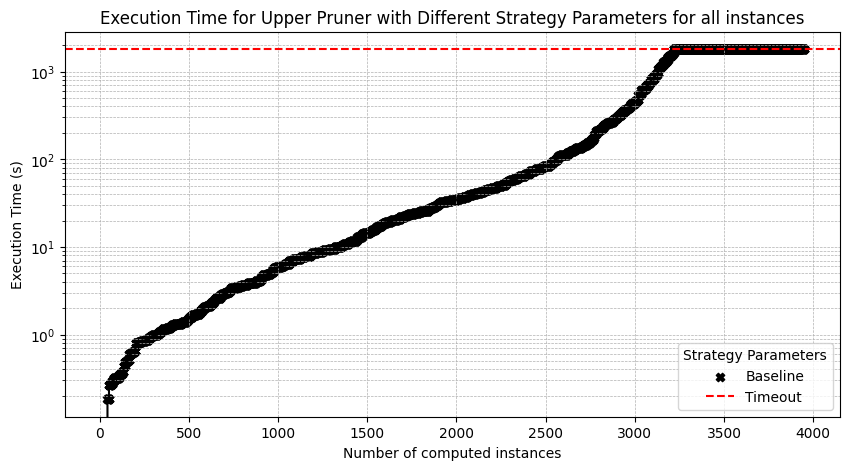

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import gc

# Drop all existing dataframes
for name in dir():
    if isinstance(eval(name), pd.core.frame.DataFrame):
        del globals()[name]

# Run garbage collection to free up memory
gc.collect()

# Load the CSV files into new Pandas DataFrames
baseline_file_path = '240730_Baseline.csv'  # Replace with your file path
df_baseline_new = pd.read_csv(baseline_file_path, delimiter=';', quotechar='"')

all_merged_file_path = '240730_RESALL_MERGED.csv'  # Replace with your file path
df_all_merged_new = pd.read_csv(all_merged_file_path, delimiter=';', quotechar='"')

# Merge the dataframes on the filename column
df_combined_new = pd.merge(df_baseline_new, df_all_merged_new, on='filename', suffixes=('_baseline', '_arg'), how='outer')

# Ensure 'strategy_param' column exists
if 'strategy_param' not in df_combined_new.columns:
    df_combined_new['strategy_param'] = 0

# Ensure 'execution_time' column exists and fill missing values for baseline data
if 'execution_time' not in df_combined_new.columns:
    df_combined_new['execution_time'] = None

if 'execution_time_baseline' in df_combined_new.columns:
    df_combined_new['execution_time'] = df_combined_new['execution_time'].fillna(df_combined_new['execution_time_baseline'])

# Create a mapping for the strategy parameters to different markers and colors
markers = {1: 'o', 2: 's', 3: '^', 0: 'X'}  # Define your strategy parameter markers
palette = {1: 'orange', 2: 'green', 3: 'blue', 0: 'black'}  # Define your strategy parameter colors
labels = {1: 'Cardinality', 2: 'Random', 3: 'Inconsistency', 0: 'Baseline'}  # Custom labels

plt.figure(figsize=(10, 5))

# Plot the baseline separately to ensure it is only plotted once
baseline_subset_new = df_combined_new[df_combined_new['strategy_param'] == 0]
if not baseline_subset_new.empty:
    baseline_subset_new = baseline_subset_new.sort_values(by='execution_time')
    baseline_subset_new['counter'] = range(1, len(baseline_subset_new) + 1)
    plt.scatter(
        x=baseline_subset_new['counter'], 
        y=baseline_subset_new['execution_time'], 
        marker=markers[0], 
        color=palette[0], 
        label=labels[0]  # Use custom labels
    )
    plt.plot(
        baseline_subset_new['counter'], 
        baseline_subset_new['execution_time'], 
        linestyle='-', 
        color=palette[0]
    )

# Plot each strategy parameter separately to apply different markers and colors
for strategy_param, marker in markers.items():
    if strategy_param != 0:  # Skip baseline as it's already plotted
        subset_new = df_combined_new[df_combined_new['strategy_param'] == strategy_param]
        if not subset_new.empty:
            # Sort the subset by execution_time
            subset_new = subset_new.sort_values(by='execution_time')
            # Create a counter for the x-axis based on the sorted order
            subset_new['counter'] = range(1, len(subset_new) + 1)

            # Plot the scatter points
            plt.scatter(
                x=subset_new['counter'],
                y=subset_new['execution_time'],
                marker=marker,
                color=palette[strategy_param],
                label=labels[strategy_param]  # Use custom labels
            )

            # Plot the lines connecting the points
            plt.plot(
                subset_new['counter'],
                subset_new['execution_time'],
                linestyle='-',
                color=palette[strategy_param]
            )

# Add a horizontal line for the timeout threshold (if applicable)
timeout_threshold = 1800  # Adjust this threshold as needed
plt.axhline(y=timeout_threshold, color='red', linestyle='--', label='Timeout')

# Customize the plot
plt.yscale('log')  # Set y-axis to logarithmic scale
plt.title('Execution Time for Upper Pruner with Different Strategy Parameters for all instances')
plt.xlabel('Number of computed instances')
plt.ylabel('Execution Time (s)')
plt.legend(title='Strategy Parameters')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Save or display the plot
plt.savefig('exe_time_allpruners_all.png', dpi=300, bbox_inches='tight')
plt.show()
